In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading data

In [10]:
DATA_PATH = '../data/transformed/transformed_data.csv'

In [11]:
df = pd.read_csv(filepath_or_buffer=DATA_PATH,
                 delimiter=',')

df.head()

,id_voluntario,cor_pele,cor_olhos,cor_cabelo_15_anos,rs1426654,rs6058017,rs1800404,rs16891982
0,EC001,Parda,Castanho,Preto,AA,NaN,NaN,NaN
1,EC002,Parda,Castanho,Castanho,GG,AA,GA,NaN
2,EC003,Parda,Castanho,Preto,GA,NaN,AA,NaN
3,EC004,Parda,Castanho,Castanho,NaN,NaN,NaN,NaN
4,EC005,Parda,Castanho,Castanho,AA,AA,AA,NaN


## Exploring the dataset

In [12]:
df.describe()

,id_voluntario,cor_pele,cor_olhos,cor_cabelo_15_anos,rs1426654,rs6058017,rs1800404,rs16891982
count,277,277,277,277,256,237,234,139
unique,277,5,4,3,3,4,3,3
top,EC001,Parda,Castanho,Castanho,AA,AA,GA,CG
freq,1,142,244,201,130,140,97,85


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id_voluntario       277 non-null    str  
 1   cor_pele            277 non-null    str  
 2   cor_olhos           277 non-null    str  
 3   cor_cabelo_15_anos  277 non-null    str  
 4   rs1426654           256 non-null    str  
 5   rs6058017           237 non-null    str  
 6   rs1800404           234 non-null    str  
 7   rs16891982          139 non-null    str  
dtypes: str(8)
memory usage: 17.4 KB


In [14]:
df.nunique()

id_voluntario         277
cor_pele                5
cor_olhos               4
cor_cabelo_15_anos      3
rs1426654               3
rs6058017               4
rs1800404               3
rs16891982              3
dtype: int64

In [15]:
df.columns

Index(['id_voluntario', 'cor_pele', 'cor_olhos', 'cor_cabelo_15_anos',
       'rs1426654', 'rs6058017', 'rs1800404', 'rs16891982'],
      dtype='str')

## Plotting simple charts

### Skin color distribution

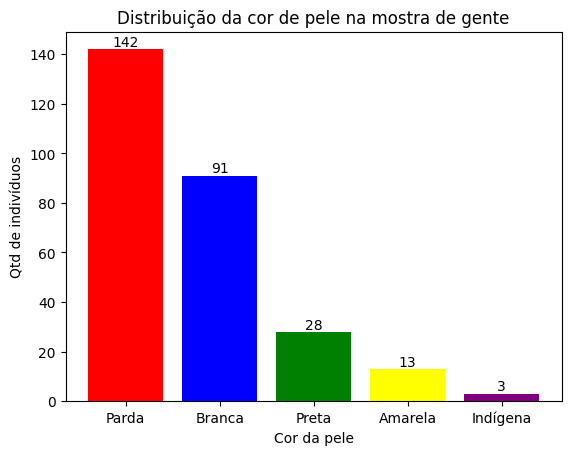

In [16]:
distribution = df['cor_pele'].value_counts()
x = distribution.index
y = distribution.values
color = ['red', 'blue', 'green', 'yellow', 'purple']

bars = plt.bar(x, y, color=color)
plt.bar_label(bars)
plt.xlabel('Cor da pele')
plt.ylabel('Qtd de indivíduos')
plt.title('Distribuição da cor de pele na mostra de gente')

plt.savefig('./pele.png')

### Hair color distribution

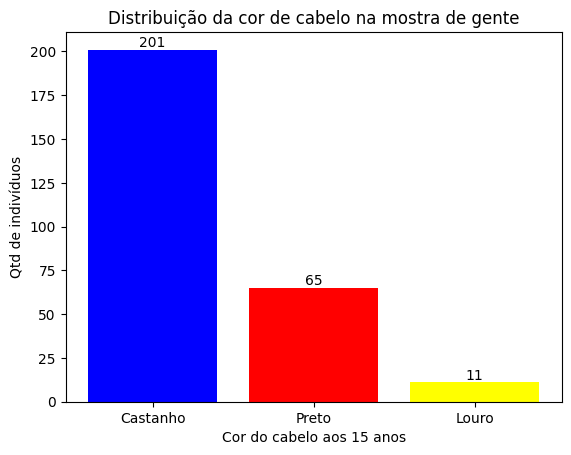

In [17]:
distribution = df['cor_cabelo_15_anos'].value_counts()
x = distribution.index
y = distribution.values
color = ['blue', 'red', 'yellow', 'purple', 'green']

bars = plt.bar(x, y, color=color)
plt.bar_label(bars)

plt.xlabel('Cor do cabelo aos 15 anos')
plt.ylabel('Qtd de indivíduos')
plt.title('Distribuição da cor de cabelo na mostra de gente')

plt.savefig('./cabelo.png')

## Eye color distribution

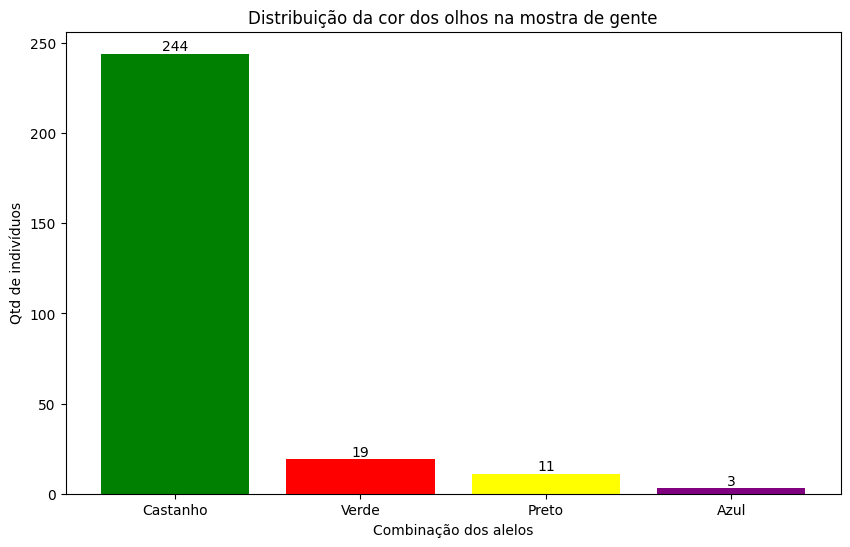

In [18]:
distribution = df['cor_olhos'].value_counts()
x = distribution.index
y = distribution.values
color = ['green', 'red', 'yellow', 'purple', 'blue']

plt.figure(figsize=(10, 6))
bars = plt.bar(x, y, color=color)

plt.bar_label(bars)
plt.xlabel('Combinação dos alelos')
plt.ylabel('Qtd de indivíduos')
plt.title('Distribuição da cor dos olhos na mostra de gente')
plt.savefig('./olhos.png')

## Cleaning some more

In [19]:
# para preencher os marcadores com valores nulos
df = df.fillna('sem alelo')

In [20]:
df.rs6058017.unique()

<StringArray>
['sem alelo', 'AA', 'AG', 'GG', 'GA']
Length: 5, dtype: str

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id_voluntario       277 non-null    str  
 1   cor_pele            277 non-null    str  
 2   cor_olhos           277 non-null    str  
 3   cor_cabelo_15_anos  277 non-null    str  
 4   rs1426654           277 non-null    str  
 5   rs6058017           277 non-null    str  
 6   rs1800404           277 non-null    str  
 7   rs16891982          277 non-null    str  
dtypes: str(8)
memory usage: 17.4 KB


## Random Forest

### Importando libs necessárias

In [22]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

### Cor da pele

In [23]:
X = df[['rs1426654', 'rs6058017', 'rs1800404', 'rs16891982']]

In [24]:
y_skin = df['cor_pele']

le_encoder = LabelEncoder()
y_skin_encoded = le_encoder.fit_transform(y_skin)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y_skin_encoded,
                                                    test_size=0.2,
                                                    random_state=41,
                                                    stratify=y_skin_encoded)

In [26]:
ohe_encoder = OneHotEncoder(drop=None,
                            sparse_output=False,
                            handle_unknown='ignore')

X_train_enc = ohe_encoder.fit_transform(X_train)
X_test_enc = ohe_encoder.transform(X_test)

smote_skin = SMOTE(random_state=42, k_neighbors=2)
X_train_skin_smote, y_train = smote_skin.fit_resample(X_train_enc, y_train)

print(f"Training set after SMOTE: {X_train_enc.shape[0]} samples")
print(f"Class distribution after SMOTE:")
for i, class_name in enumerate(le_encoder.classes_):
    count = (y_train == i).sum()
    print(f"  {class_name}: {count}")

Training set after SMOTE: 221 samples
Class distribution after SMOTE:
  Amarela: 113
  Branca: 113
  Indígena: 113
  Parda: 113
  Preta: 113


In [27]:
rf_skin = RandomForestClassifier(n_estimators=200, 
                            max_depth=15,
                            min_samples_leaf=2,
                            random_state=42,
                            n_jobs=-1)

rf_skin.fit(X_train_skin_smote, y_train)

y_pred_skin = rf_skin.predict(X_test_enc)

In [28]:
present = np.unique(y_test)


print("Accuracy:", accuracy_score(y_test, y_pred_skin))
print("Balanced acc:", balanced_accuracy_score(y_test, y_pred_skin))
print("Macro F1:", f1_score(y_test, y_pred_skin, average='macro'))
print(classification_report(y_test, y_pred_skin, labels=present, target_names=le_encoder.inverse_transform(present), zero_division=0))


Accuracy: 0.48214285714285715
Balanced acc: 0.35153256704980845
Macro F1: 0.340080971659919
              precision    recall  f1-score   support

     Amarela       0.00      0.00      0.00         3
      Branca       0.50      0.56      0.53        18
       Parda       0.54      0.52      0.53        29
       Preta       0.29      0.33      0.31         6

    accuracy                           0.48        56
   macro avg       0.33      0.35      0.34        56
weighted avg       0.47      0.48      0.47        56



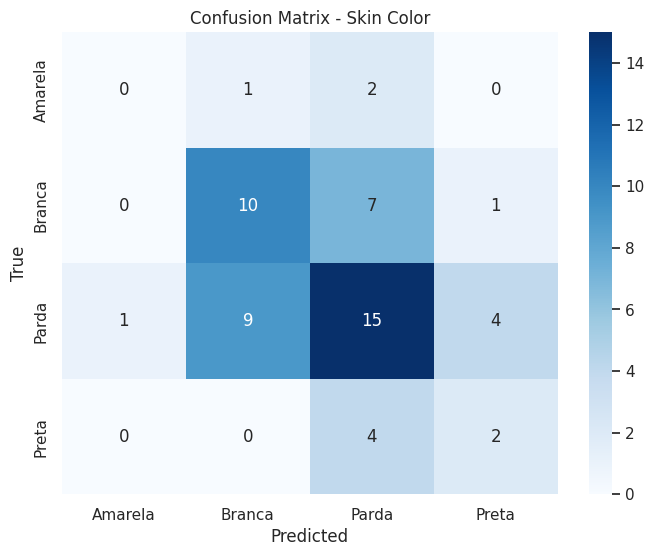

In [29]:
cmatrix = confusion_matrix(y_test, y_pred_skin)

plt.figure(figsize=(8, 6))
sns.set(font_scale=1)
sns.heatmap(cmatrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_encoder.inverse_transform(present),
            yticklabels=le_encoder.inverse_transform(present))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Skin Color')
plt.show()

### Cor dos olhos

In [30]:
y_eye = df['cor_olhos']

le_eye = LabelEncoder()
y_eye_encoded = le_eye.fit_transform(y_eye)

In [31]:
X_train_eye, X_test_eye, y_train_eye, y_test_eye = train_test_split(
    X, y_eye_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_eye_encoded)

In [32]:
ohe_encoder = OneHotEncoder(drop=None,
                            sparse_output=False,
                            handle_unknown='ignore')

X_train_eye_enc = ohe_encoder.fit_transform(X_train_eye)
X_test_eye_enc = ohe_encoder.transform(X_test_eye)

In [33]:
smote_eye = SMOTE(random_state=42, k_neighbors=1)
X_train_eye_smote, y_train_eye_smote = smote_eye.fit_resample(X_train_eye_enc, y_train_eye)


In [34]:
print(f"Eye Color - Training set after SMOTE: {X_train_eye_enc.shape[0]} samples")
print(f"Class distribution:")
for i, class_name in enumerate(le_eye.classes_):
    count = (y_train_eye == i).sum()
    print(f"  {class_name}: {count}")


Eye Color - Training set after SMOTE: 221 samples
Class distribution:
  Azul: 2
  Castanho: 195
  Preto: 9
  Verde: 15


In [35]:
rf_eye = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=2, 
                                 random_state=42, n_jobs=-1)
rf_eye.fit(X_train_eye_smote, y_train_eye_smote)
y_pred_eye = rf_eye.predict(X_test_eye_enc)

In [36]:
print("\n" + "="*50)
print("EYE COLOR PREDICTION RESULTS")
print("="*50)
present_eye = np.unique(y_test_eye)
print("Accuracy:", accuracy_score(y_test_eye, y_pred_eye))
print("Balanced acc:", balanced_accuracy_score(y_test_eye, y_pred_eye))
print("Macro F1:", f1_score(y_test_eye, y_pred_eye, average='macro'))
print(classification_report(y_test_eye, y_pred_eye, labels=present_eye, 
                           target_names=[str(x) for x in le_eye.inverse_transform(present_eye)], zero_division=0))



EYE COLOR PREDICTION RESULTS
Accuracy: 0.8214285714285714
Balanced acc: 0.29209183673469385
Macro F1: 0.28055555555555556
              precision    recall  f1-score   support

        Azul       0.00      0.00      0.00         1
    Castanho       0.88      0.92      0.90        49
       Preto       0.00      0.00      0.00         2
       Verde       0.20      0.25      0.22         4

    accuracy                           0.82        56
   macro avg       0.27      0.29      0.28        56
weighted avg       0.79      0.82      0.80        56



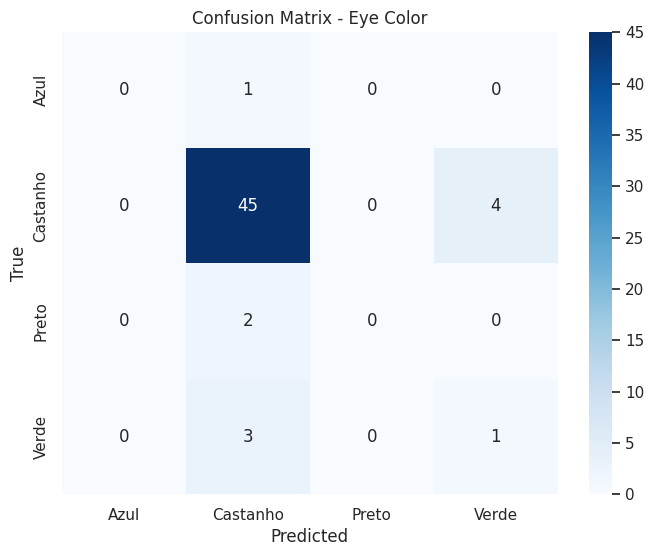

In [37]:
cmatrix = confusion_matrix(y_test_eye, y_pred_eye)

plt.figure(figsize=(8, 6))
sns.set(font_scale=1)
sns.heatmap(cmatrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_eye.inverse_transform(present_eye),
            yticklabels=le_eye.inverse_transform(present_eye))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Eye Color')
plt.show()

### Cor do cabelo

In [38]:
y_hair = df['cor_cabelo_15_anos']

le_hair = LabelEncoder()
y_hair_encoded = le_hair.fit_transform(y_hair)

In [39]:
X_train_hair, X_test_hair, y_train_hair, y_test_hair = train_test_split(
    X, y_hair_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_hair_encoded)

In [40]:
ohe_encoder = OneHotEncoder(drop=None,
                            sparse_output=False,
                            handle_unknown='ignore')

X_train_hair_enc = ohe_encoder.fit_transform(X_train_hair)
X_test_hair_enc = ohe_encoder.transform(X_test_hair)


In [41]:
smote_hair = SMOTE(random_state=42, k_neighbors=1)
X_train_hair_enc_smote, y_train_hair = smote_hair.fit_resample(X_train_hair_enc, y_train_hair)


In [42]:
print(f"Hair Color - Training set after SMOTE: {X_train_hair_enc_smote.shape[0]} samples")
print(f"Class distribution:")
for i, class_name in enumerate(le_hair.classes_):
    count = (y_train_hair == i).sum()
    print(f"  {class_name}: {count}")


Hair Color - Training set after SMOTE: 480 samples
Class distribution:
  Castanho: 160
  Louro: 160
  Preto: 160


In [43]:
rf_hair = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=2, 
                                 random_state=42, n_jobs=-1)
rf_hair.fit(X_train_hair_enc_smote, y_train_hair)
y_pred_hair = rf_hair.predict(X_test_hair_enc)


In [44]:
print("\n" + "="*50)
print("HAIR COLOR PREDICTION RESULTS")
print("="*50)
present_hair = np.unique(y_test_hair)
print("Accuracy:", accuracy_score(y_test_hair, y_pred_hair))
print("Balanced acc:", balanced_accuracy_score(y_test_hair, y_pred_hair))
print("Macro F1:", f1_score(y_test_hair, y_pred_hair, average='macro'))
print(classification_report(y_test_hair, y_pred_hair, labels=present_hair, 
                           target_names=[str(x) for x in le_hair.inverse_transform(present_hair)], zero_division=0))



HAIR COLOR PREDICTION RESULTS
Accuracy: 0.4642857142857143
Balanced acc: 0.4224515322076298
Macro F1: 0.42368839427662963
              precision    recall  f1-score   support

    Castanho       0.67      0.54      0.59        41
       Louro       0.50      0.50      0.50         2
       Preto       0.14      0.23      0.18        13

    accuracy                           0.46        56
   macro avg       0.44      0.42      0.42        56
weighted avg       0.54      0.46      0.49        56



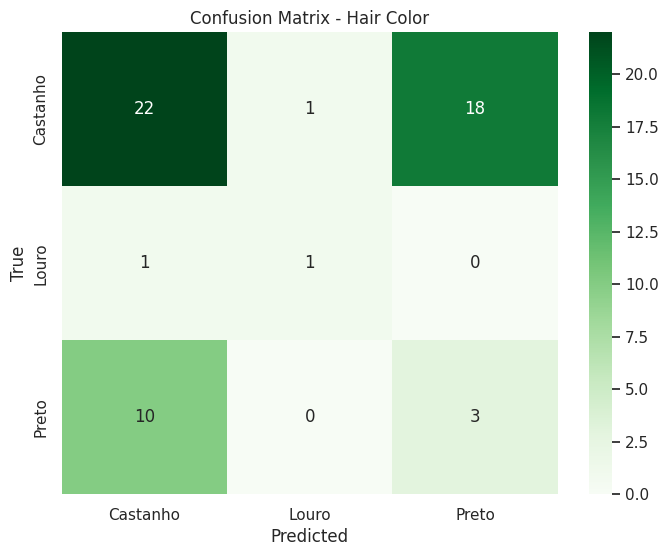

In [45]:
cmatrix_hair = confusion_matrix(y_test_hair, y_pred_hair)

plt.figure(figsize=(8, 6))
sns.set(font_scale=1)
sns.heatmap(cmatrix_hair, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_hair.inverse_transform(present_hair),
            yticklabels=le_hair.inverse_transform(present_hair))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Hair Color')
plt.show()